# Gráficos básicos

Crea un programa Elecciones.py que va a representar en un gráfico los resultados de unas elecciones a las que concurren cuatro partidos políticos: PA, PB, PC y PD.

El usuario deberá introducir en una línea los votos recibidos en forma de números enteros para que representen a cada partido (1 = PA, 2 = PB, 3 = PC, 4 = PD. Por ejemplo: 1 1 2 1 1 2 4 3 2 1)

Se mostrará un gráfico circular con el resultado final de las elecciones. Junto al nombre de cada partido debe aparecer el porcentaje de voto total.

Cualquier número que no esté en el rango indicado (de 1 a 4) deberá descartarse del conteo final.

Introduzca votos separados por un espacio: 1 2 2 2 3 4

Recuento de votos válidos:
PA    1
PB    3
PC    1
PD    1
Name: count, dtype: int64

Porcentajes de voto:
PA    16.67
PB    50.00
PC    16.67
PD    16.67
Name: count, dtype: float64


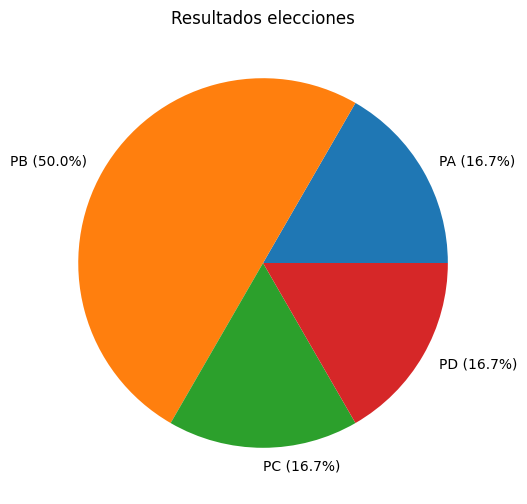

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

datos_entrada = input("Introduzca votos separados por un espacio: ")

# Convertimos la entrada en una lista de enteros válidos
try:
  lista_votos = list(map(int, datos_entrada.split()))
except ValueError:
  print("Error: introduzca solo números enteros del 1 al 4 (ambos inclusive.)")
  exit()

# Filtramos solo los votos válidos (1 a 4)
votos_validos = [
    v
    for v in lista_votos
    if 1 <= v <= 4
]

if not votos_validos:
  print("No hay votos válidos.")

# Creamos la Serie de Pandas con los votos válidos
serie_votos = pd.Series(votos_validos)

# Contamos los votos por partido y los ordenamos
recuento = serie_votos.value_counts().sort_index()

# Asignamos nombres a los partidos
partidos = ['PA', 'PB', 'PC', 'PD']
recuento.index = partidos[:len(recuento)]

# Calculamos porcentajes
porcentajes = (recuento / recuento.sum()) * 100

# Mostramos los resultados por consola
print(f"\nRecuento de votos válidos:\n{recuento}")
print(f"\nPorcentajes de voto:\n{porcentajes.round(2)}")

# Cremos el gráfico circular (pie chart)
plt.figure(figsize=(6, 6))
plt.pie(
    recuento,
    labels=[f"{p} ({pct:.1f}%)"
    for p, pct in zip(recuento.index, porcentajes)]
)
plt.title("Resultados")
plt.show()